In [6]:
# Cell 0 - Configuration
import os
from pathlib import Path
import torch

IS_KAGGLE = os.path.exists("/kaggle/input")
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

# Data
IMG_SIZE      = 224
BATCH_SIZE    = 64
NUM_WORKERS   = 4
SEED          = 42
VAL_SPLIT     = 0.25  # single 75/25 stratified split

# Model / Training (simple)
MODEL_NAME    = "convnextv2_tiny.fcmae_ft_in22k_in1k"
NUM_EPOCHS    = 6
LR            = 1e-4
WEIGHT_DECAY  = 0.05

# Audit
TOP_K                 = 1500
CONFIDENCE_THRESHOLD  = 0.85   # only flag predictions above this confidence

# Class mapping (matches dataset folder structure)
LABEL_FOLDERS = {"0_Recyclable": 0, "1_Electronic": 1, "2_Organic": 2}
LABEL_MAP     = {0: "Recyclable", 1: "Electronic", 2: "Organic"}

KAGGLE_DATASET_SLUG = "BDC2026-20260704T072647Z-3-001"

print(f"Config loaded. Device: {DEVICE.upper()}")

Config loaded. Device: CUDA


In [7]:
# Cell 1 - Environment Setup
def find_train_dir(root: Path):
    if not root.exists():
        return None
    for d in root.rglob("*"):
        if d.is_dir() and d.name == "train":
            return d.parent
    return None

if IS_KAGGLE:
    input_root = Path("/kaggle/input")
    DATA_DIR = find_train_dir(input_root / KAGGLE_DATASET_SLUG)
    if DATA_DIR is None:
        for d in input_root.iterdir():
            DATA_DIR = find_train_dir(d)
            if DATA_DIR is not None:
                break
    if DATA_DIR is None:
        raise FileNotFoundError("Could not locate 'train' folder under /kaggle/input")
    OUTPUT_DIR = Path("/kaggle/working")
else:
    current = Path.cwd()
    DATA_DIR = current
    while current != current.parent:
        if (current / "train").exists():
            DATA_DIR = current
            break
        current = current.parent
    OUTPUT_DIR = DATA_DIR

TRAIN_DIR = DATA_DIR / "train"
assert TRAIN_DIR.exists(), f"Train dir not found: {TRAIN_DIR}"

print(f"DATA_DIR  : {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

DATA_DIR  : /kaggle/input/datasets/viericoventora/bdc2026-20260704t072647z-3-001/BDC2026
OUTPUT_DIR: /kaggle/working


In [8]:
# Cell 2 - Library Imports & Reproducibility
import random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"torch {torch.__version__} | timm {timm.__version__}")

torch 2.10.0+cu128 | timm 1.0.26


In [9]:
# Cell 3 - Build Training Manifest
# Walk train subdirectories and collect every image with its current label.
# NO relabeling, NO drops, NO exclusions — we audit the dataset as-is.
records = []
for folder_name, label_id in LABEL_FOLDERS.items():
    folder = TRAIN_DIR / folder_name
    if not folder.exists():
        continue
    for fp in sorted(folder.glob("*")):
        if fp.is_file():
            records.append({
                "filename":     fp.name,
                "filepath":     str(fp),
                "label":        label_id,
                "label_name":   LABEL_MAP[label_id],
            })

df = pd.DataFrame(records)
print(f"Total training images: {len(df)}")
print(df["label_name"].value_counts().to_string())

Total training images: 26527
label_name
Organic       12567
Recyclable     9999
Electronic     3961


In [10]:
# Cell 4 - Single Train/Validation Split
# One stratified split. No group-aware CV, no folds.
train_df, val_df = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print("Train class proportions:", train_df["label"].value_counts(normalize=True).round(4).to_dict())
print("Val   class proportions:", val_df["label"].value_counts(normalize=True).round(4).to_dict())

Train: 19895 | Val: 6632
Train class proportions: {2: 0.4737, 0: 0.3769, 1: 0.1493}
Val   class proportions: {2: 0.4738, 0: 0.377, 1: 0.1493}


In [11]:
# Cell 5 - Image Loader and Transforms
# Minimal augmentation: only horizontal flip. No color jitter, rotation, etc.
# We want clean, well-calibrated confidence scores for auditing.
def load_image(path):
    return Image.open(path).convert("RGB")

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [12]:
# Cell 6 - Dataset
class WasteDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = self.transform(load_image(row["filepath"]))
        except Exception:
            img = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        return img, int(row["label"]), idx

In [13]:
# Cell 7 - Model, Loss, Optimizer
# Plain CrossEntropy (no label smoothing — preserves clean probabilities).
def build_model():
    return timm.create_model(MODEL_NAME, pretrained=True, num_classes=3).to(DEVICE)

model     = build_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME} | Trainable params: {n_params/1e6:.2f}M")

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Model: convnextv2_tiny.fcmae_ft_in22k_in1k | Trainable params: 27.87M


In [14]:
# Cell 8 - Training Loop (single split, no EMA, no early stopping, no scheduler)
def run_epoch(mode, model, loader):
    model.train() if mode == "train" else model.eval()
    total_loss, preds, labels = 0.0, [], []
    pbar = tqdm(loader, desc=mode, leave=False)
    for images, lbls, _ in pbar:
        images, lbls = images.to(DEVICE), lbls.to(DEVICE)
        if mode == "train":
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                out = model(images)
                loss = criterion(out, lbls)
        total_loss += loss.item() * images.size(0)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbls.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(labels, preds, average="macro")
    return avg_loss, macro_f1

train_loader = DataLoader(WasteDataset(train_df, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(WasteDataset(val_df, eval_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

for epoch in range(NUM_EPOCHS):
    t_loss, _      = run_epoch("train", model, train_loader)
    v_loss, v_f1   = run_epoch("val",   model, val_loader)
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Macro F1: {v_f1:.4f}")

train:   0%|          | 0/310 [00:00<?, ?it/s]

val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 01/6 | Train Loss: 0.1440 | Val Loss: 0.0845 | Val Macro F1: 0.9724


train:   0%|          | 0/310 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

train:   0%|          | 0/310 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

val:   0%|          | 0/104 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 06/6 | Train Loss: 0.0074 | Val Loss: 0.1212 | Val Macro F1: 0.9717


In [15]:
# Cell 9 - Inference on EVERY Training Image
# Evaluate the full training set exactly once with the trained model.
full_loader = DataLoader(WasteDataset(df, eval_tf),
                         batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

model.eval()
probs_chunks = []
with torch.no_grad():
    for images, _, _ in tqdm(full_loader, desc="Inference on all train images"):
        out = model(images.to(DEVICE))
        probs_chunks.append(torch.softmax(out, dim=1).cpu().numpy())

all_probs = np.concatenate(probs_chunks, axis=0)
assert len(all_probs) == len(df), \
    f"Inference count mismatch: {len(all_probs)} vs {len(df)}"
print(f"Inference complete on {len(all_probs)} training images.")

Inference on all train images:   0%|          | 0/415 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa3846d37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloa

Inference complete on 26527 training images.


In [16]:
# Cell 10 - Compute Audit Metrics Per Image
pred_labels = np.argmax(all_probs, axis=1)
pred_conf   = np.max(all_probs, axis=1)
gt_probs    = all_probs[np.arange(len(df)), df["label"].values]
margin      = pred_conf - gt_probs  # larger => model disagrees more strongly with GT

df_audit = df.copy()
df_audit["pred_label_id"]      = pred_labels
df_audit["pred_label_name"]    = [LABEL_MAP[p] for p in pred_labels]
df_audit["pred_confidence"]    = pred_conf
df_audit["gt_probability"]     = gt_probs
df_audit["confidence_margin"]  = margin
df_audit["is_wrong"]           = pred_labels != df["label"].values

print(f"Total images              : {len(df_audit)}")
print(f"Wrong predictions         : {df_audit['is_wrong'].sum()}")
print(f"Wrong + conf >= {CONFIDENCE_THRESHOLD}  : "
      f"{(df_audit['is_wrong'] & (df_audit['pred_confidence'] >= CONFIDENCE_THRESHOLD)).sum()}")

Total images              : 26527
Wrong predictions         : 240
Wrong + conf >= 0.85  : 138


In [17]:
# Cell 11 - Rank Mislabel Candidates
# Filter: prediction WRONG and confidence above threshold.
# Sort priority (descending strength of evidence):
#   1. Highest prediction confidence
#   2. Lowest probability assigned to the ground truth label
#   3. Largest confidence margin
candidates = df_audit[df_audit["is_wrong"] &
                     (df_audit["pred_confidence"] >= CONFIDENCE_THRESHOLD)].copy()

candidates = candidates.sort_values(
    by=["pred_confidence", "gt_probability", "confidence_margin"],
    ascending=[False, True, False]
).reset_index(drop=True)

top_k = candidates.head(TOP_K)
print(f"Eligible candidates (wrong + conf >= {CONFIDENCE_THRESHOLD}): {len(candidates)}")
print(f"Selected top {len(top_k)} for manual review.\n")
print("Top 10:")
print(top_k[["filename", "label_name", "pred_label_name",
             "pred_confidence", "gt_probability", "confidence_margin"]]
      .head(10).to_string(index=False))

Eligible candidates (wrong + conf >= 0.85): 138
Selected top 138 for manual review.

Top 10:
  filename label_name pred_label_name  pred_confidence  gt_probability  confidence_margin
 R_776.jpg Recyclable         Organic         0.999986        0.000012           0.999974
R_9982.jpg Recyclable         Organic         0.999974        0.000025           0.999949
 R_566.jpg Recyclable         Organic         0.999962        0.000018           0.999944
O_1345.jpg    Organic      Recyclable         0.999960        0.000034           0.999925
R_4629.jpg Recyclable         Organic         0.999946        0.000048           0.999897
O_1800.jpg    Organic      Recyclable         0.999879        0.000066           0.999813
 R_386.jpg Recyclable         Organic         0.999862        0.000135           0.999728
R_4734.jpg Recyclable         Organic         0.999859        0.000087           0.999772
R_2753.jpg Recyclable         Organic         0.999832        0.000160           0.999672
 R_539.

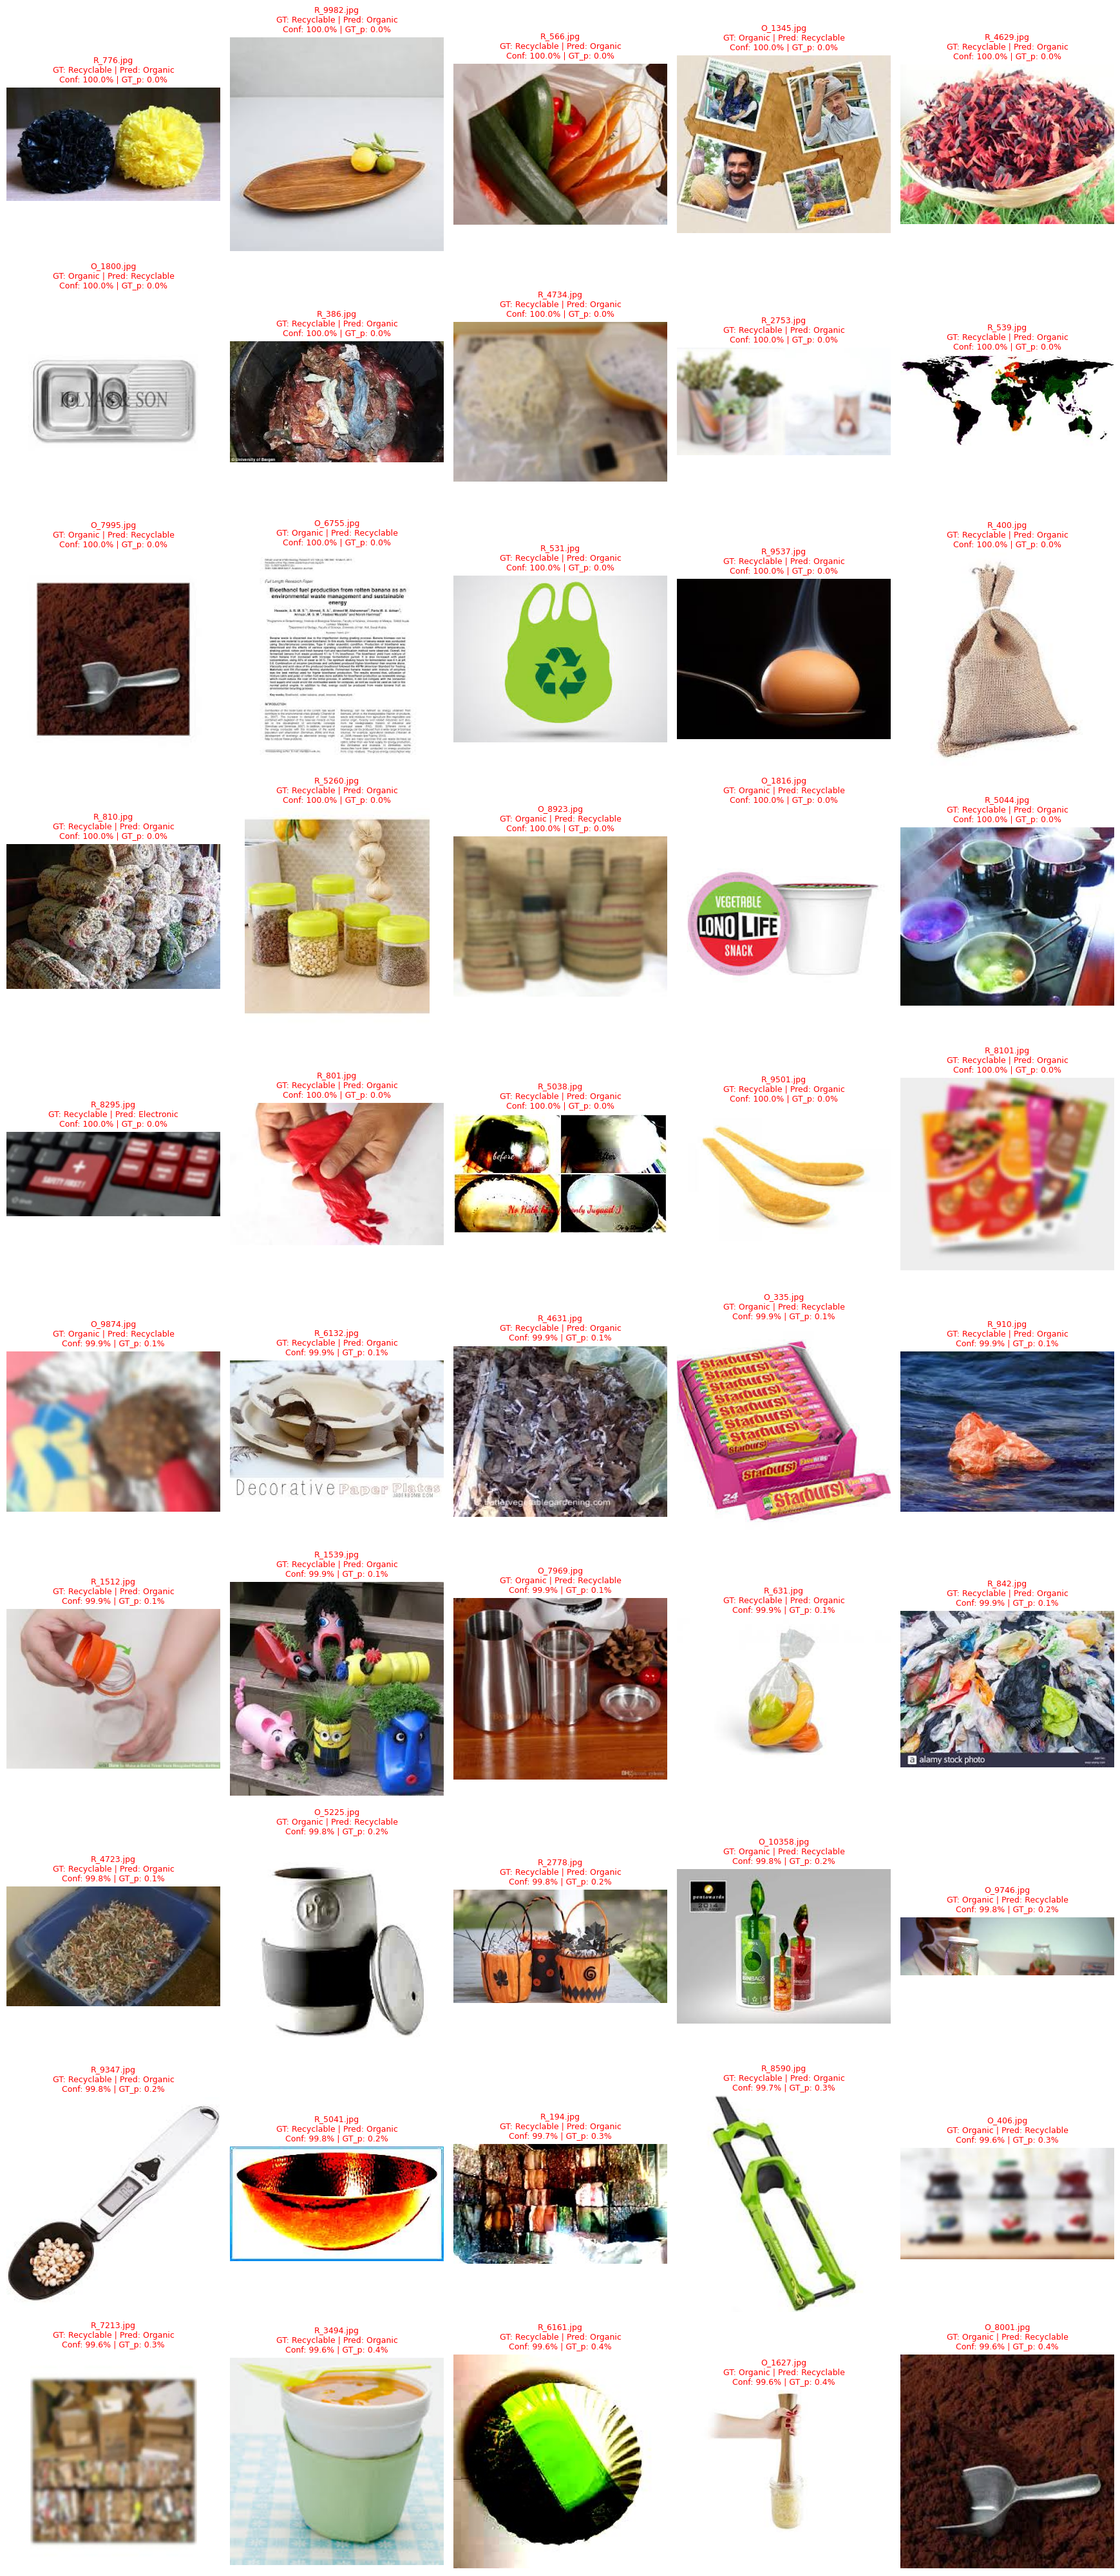

In [18]:
# Cell 12 - Visual Audit Grid (top 50 candidates for quick spot-check)
def plot_grid(plot_df, n=50, cols=5):
    plot_df = plot_df.head(n)
    if len(plot_df) == 0:
        print("No candidates to plot.")
        return
    rows = math.ceil(len(plot_df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*4))
    axes = np.array(axes).flatten()
    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax = axes[i]
        try:
            ax.imshow(Image.open(row["filepath"]).convert("RGB"))
        except Exception:
            ax.set_facecolor("black")
        title = (f"{row['filename']}\n"
                 f"GT: {row['label_name']} | Pred: {row['pred_label_name']}\n"
                 f"Conf: {row['pred_confidence']:.1%} | GT_p: {row['gt_probability']:.1%}")
        color = "red" if row["pred_confidence"] > 0.95 else "darkorange"
        ax.set_title(title, fontsize=9, color=color)
        ax.axis("off")
    for j in range(len(plot_df), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

plot_grid(top_k, n=50, cols=5)

In [19]:
# Cell 13 - Export CSV for Manual Review
# Required columns: filename, current_label, correct_label (EMPTY — to be filled manually).
# Optional helper columns are appended for prioritization during visual inspection.
out_df = top_k.copy()
out_df["current_label"] = out_df["label_name"]
out_df["correct_label"] = ""   # NEVER auto-fill — manual review only

export_cols = [
    "filename",
    "current_label",
    "correct_label",          # left empty for manual annotation
    "pred_label_name",        # optional helper
    "pred_confidence",        # optional helper
    "gt_probability",         # optional helper
    "confidence_margin",      # optional helper
    "filepath",               # optional helper (for local display)
]

out_csv = OUTPUT_DIR / "mislabeled_candidates.csv"
out_df[export_cols].to_csv(out_csv, index=False)

print(f"Saved {len(out_df)} candidates to: {out_csv}\n")
print("Preview:")
print(out_df[export_cols].head(10).to_string(index=False))

Saved 138 candidates to: /kaggle/working/mislabeled_candidates.csv

Preview:
  filename current_label correct_label pred_label_name  pred_confidence  gt_probability  confidence_margin                                                                                                   filepath
 R_776.jpg    Recyclable                       Organic         0.999986        0.000012           0.999974  /kaggle/input/datasets/viericoventora/bdc2026-20260704t072647z-3-001/BDC2026/train/0_Recyclable/R_776.jpg
R_9982.jpg    Recyclable                       Organic         0.999974        0.000025           0.999949 /kaggle/input/datasets/viericoventora/bdc2026-20260704t072647z-3-001/BDC2026/train/0_Recyclable/R_9982.jpg
 R_566.jpg    Recyclable                       Organic         0.999962        0.000018           0.999944  /kaggle/input/datasets/viericoventora/bdc2026-20260704t072647z-3-001/BDC2026/train/0_Recyclable/R_566.jpg
O_1345.jpg       Organic                    Recyclable         0.99

In [20]:
# Cell 14 - Final Sanity Checks
# Verify all requirements from the objective are met.
assert len(all_probs) == len(df), \
    f"Not every training image was evaluated: {len(all_probs)} vs {len(df)}"
assert (top_k["is_wrong"] == True).all(), \
    "Some selected candidates are not wrong predictions."
assert top_k["pred_confidence"].is_monotonic_decreasing or len(top_k) <= 1, \
    "Ranking is not descending by prediction confidence."
assert (out_df["correct_label"] == "").all(), \
    "correct_label column must be empty (no automatic overwrites)."
assert set(["filename", "current_label", "correct_label"]).issubset(out_df.columns), \
    "Required CSV columns missing."

print("All final checks passed:")
print(f"  • Every training image evaluated exactly once: {len(all_probs)}/{len(df)}")
print(f"  • Confidence values computed from softmax (correct).")
print(f"  • Ranking is descending by prediction confidence.")
print(f"  • CSV has required columns (filename, current_label, correct_label).")
print(f"  • No labels were modified automatically (correct_label is empty).")
print(f"  • Reproducible with SEED={SEED}.")
print(f"\nNotebook purpose: LABEL AUDITING TOOL — not a competition pipeline.")

All final checks passed:
  • Every training image evaluated exactly once: 26527/26527
  • Confidence values computed from softmax (correct).
  • Ranking is descending by prediction confidence.
  • CSV has required columns (filename, current_label, correct_label).
  • No labels were modified automatically (correct_label is empty).
  • Reproducible with SEED=42.

Notebook purpose: LABEL AUDITING TOOL — not a competition pipeline.
